# Comparison between Early Mesoderm populations

In [1]:
here::i_am("revisions/02_EarlyMes_comparison/differential.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(ArchR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

args$logFC_thr = 0.25
args$FDR_thr = 0.05

# outdir
args$outdir = file.path(io$basedir, 'results/revisions/02_EarlyMes_comparison/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
# Load meta
meta = fread(args$metadata)[genotype == 'WT']

#### Load Data

In [4]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

# Convert to Seurat
seurat = as.Seurat(rna.sce)

In [5]:
unique(seurat$genotype)

[1] "WT"

In [6]:
# Define functions
find_DEGs_seurat = function(fr_cells, bg_cells, logFC_thr = args$logFC_thr, FDR_thr = args$FDR_thr, test = 'wilcox', sample_cells = NULL){
    tmp = seurat[, c(bg_cells, fr_cells)]
    tmp$group = ifelse(colnames(tmp) %in% fr_cells, 'fr', 'bg')
    
    if(!is.null(sample_cells)){
     tmp1 = tmp[,bg_cells]
     tmp1 = tmp1[,sample(colnames(tmp1), sample_cells)]

     tmp2 = tmp[,fr_cells]
     tmp2 = tmp2[,sample(colnames(tmp2), sample_cells)]
    
     tmp = merge(tmp1, tmp2)
    }
    
    Idents(tmp) = tmp$group
    
    markers_tmp = FindMarkers(tmp, ident.1 = "fr", ident.2 = "bg",
      logfc.threshold = logFC_thr, test.use = test)
    
    if(nrow(markers_tmp)>0){
        tmp = as.data.table(markers_tmp, keep.rownames=T) %>%
            setnames('rn', 'gene') %>% 
            .[,sig:=ifelse(p_val_adj <= FDR_thr, TRUE, FALSE)]
        return(tmp)
    }
}  

# volcano plot
volcano_plot_seurat = function(dt, ntop=5, logFC_thr = args$logFC_thr, FDR_thr = args$FDR_thr, title=NULL){
    tmp = dt[,sign:=ifelse(p_val_adj < FDR_thr & abs(avg_log2FC) > logFC_thr, ifelse(avg_log2FC>0, 'pos', 'neg'), 'nonsig')] %>%
        .[order(p_val_adj)] #(-abs(avg_log2FC))]
    labels = tmp[, head(.SD, ntop),  by=sign][sign!='nonsig']
    
    negative_hits <- tmp[sign == 'neg',gene]
    positive_hits <- tmp[sign == 'pos',gene]
    all <- nrow(tmp[!is.na(sign)])
    
    ylim = max(-log10(tmp$p_val_adj))
    xlim = max(abs(tmp$avg_log2FC))
    
    p = ggplot(tmp, aes(avg_log2FC, -log10(p_val_adj), col=sign)) + 
        geom_point() +  
        scale_colour_manual(values=c('pos' = 'red', 'neg' = 'blue', 'nonsig' = 'black')) + 
        geom_vline(xintercept=c(-logFC_thr, logFC_thr),  linetype = "longdash") +
        geom_vline(xintercept=0, color='orange', linetype = "longdash") +
        geom_hline(yintercept=-log10(FDR_thr),  linetype = "longdash") + 
        ggrepel::geom_text_repel(data=labels, aes(label=gene), 
                                 color='black',
                                 size=5,
                                 box.padding = 0.5, 
                                 max.overlaps = Inf,
                                 bg.color='white', 
                                 bg.r = 0.1) + 
        # ylim(c(0, ylim*1.2)) + 
        annotate("text", x=0, y=ylim*1.1, size=6, label=sprintf("(%d)", all)) +
        annotate("text", x=-xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (-)",length(negative_hits))) +
        annotate("text", x=xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (+)",length(positive_hits))) +
        xlim(c(-max(abs(tmp$avg_log2FC)), max(abs(tmp$avg_log2FC)))) + 
        ggtitle(title) + 
        theme_bw() + 
        theme(text = element_text(size=15, color='black'),
             axis.text = element_text(size=15, color='black'),
             legend.position = 'none',
             plot.title = element_text(hjust=0.5))

    
    return(p)
}

In [7]:
fr_cells = meta[celltype_v2 == 'Early_Mes_EOd' & genotype == 'WT', cell]
bg_cells = meta[celltype_v2 == 'Early_Mes_EOi' & genotype == 'WT', cell]

In [10]:
DEG = find_DEGs_seurat(fr_cells, bg_cells, logFC_thr = 0, sample_cells = NULL)

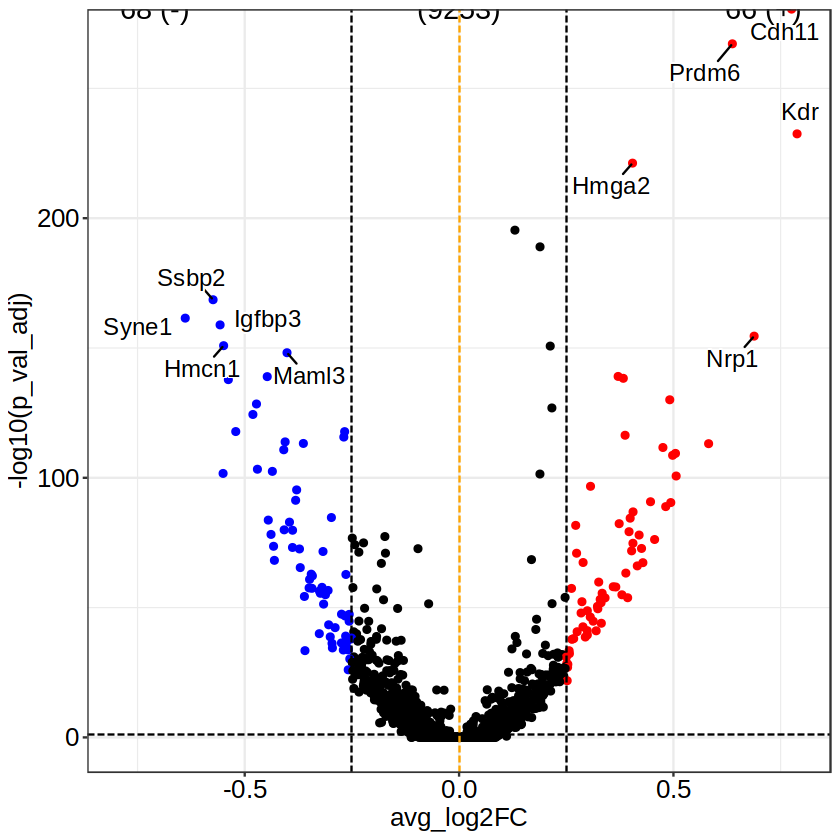

In [14]:
volcano_plot_seurat(DEG, logFC_thr = 0.25)

In [15]:
fwrite(DEG, file.path(args$outdir, 'DEGs_seurat.csv'), sep = ',')

In [16]:
volcano_plot = function(dt, ntop=5, logFC_thr = args$logFC_thr, FDR_thr = args$FDR_thr, xlim=5, ylim=40, title=NULL){
    tmp = dt[,sign:=ifelse(padj_fdr < FDR_thr & abs(logFC) > logFC_thr, ifelse(logFC>0, 'pos', 'neg'), 'nonsig')] %>%
        #.[order(-abs(logFC))] %>% 
        .[order(padj_fdr)] %>% 
        .[,logFC_plot:=ifelse(logFC<=-xlim, -xlim, ifelse(logFC>=xlim, xlim, logFC))] %>%
        .[,log10_padj_fdr:=ifelse(-log10(padj_fdr)>=ylim, ylim, -log10(padj_fdr))]
    
    labels = tmp[, head(.SD, ntop),  by=sign][sign!='nonsig']
    
    negative_hits <- tmp[sign == 'neg',gene]
    positive_hits <- tmp[sign == 'pos',gene]
    all <- nrow(tmp[!is.na(sign)])
    
    p = ggplot(tmp, aes(logFC_plot, log10_padj_fdr, col=sign, size = sign)) + 
        geom_point() + 
        scale_colour_manual(values=c('pos' = 'red', 'neg' = 'blue', 'nonsig' = 'black')) + 
        scale_size_manual(values=c('pos' = 1, 'neg' = 1, 'nonsig' = 0.2)) + 
        geom_vline(xintercept=c(-logFC_thr, logFC_thr),  linetype = "longdash") +
        geom_segment(aes(x=0, xend=0, y=0, yend=ylim*1.05), color="orange", linewidth=0.5) +
        geom_hline(yintercept=-log10(FDR_thr),  linetype = "longdash") + 
        ggrepel::geom_text_repel(data=labels, aes(label=gene), 
                                 color='black',
                                 size=5,
                                 box.padding = 0.5, 
                                 max.overlaps = Inf,
                                 bg.color='white', 
                                 bg.r = 0.1) + 
        scale_x_continuous(limits=c(-xlim*1.05,xlim*1.05), expand = c(0,0)) +
        scale_y_continuous(limits=c(0,ylim*1.2), expand = c(0,0)) +
        annotate("text", x=0, y=ylim*1.1, size=6, label=sprintf("(%d)", all)) +
        annotate("text", x=-xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (-)",length(negative_hits))) +
        annotate("text", x=xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (+)",length(positive_hits))) +
        #xlim(c(-max(abs(tmp$logFC)), max(abs(tmp$logFC)))) + 
        ggtitle(title) + 
        theme_bw() + 
        theme(text = element_text(size=15, color='black'),
             axis.text = element_text(size=15, color='black'),
             legend.position = 'none',
              plot.title = element_text(hjust=0.5))
    
    return(p)
}

In [17]:
cell_metadata.dt = meta[genotype == 'WT']
cell_metadata.dt = cell_metadata.dt[,group:=paste0(celltype_v2, '.', genotype)]

args$min_cells = 25
args$fraction_cells_per_replicate = 0.4
args$nrep = 5
args$min_CDR = 0.30

# Define groups
opts$groups <- c(args$groupA,args$groupB)

In [18]:
##################################
## Create pseudobulk replicates ##
##################################

cell2replicate.dt <- lapply(unique(cell_metadata.dt$group), function(i){
  tmp <- cell_metadata.dt[group==i]
  if ((args$fraction_cells_per_replicate*nrow(tmp))<=args$min_cells) {
    return(NULL) # ncells_per_replicate <- args$min_cells
  } else {
    ncells_per_replicate <- round(args$fraction_cells_per_replicate*nrow(tmp))

    seq(1,args$nrep) %>% map(function(j) {
    tmp[sample.int(nrow(tmp),ncells_per_replicate, replace=F)] %>% 
      .[,replicate:=sprintf("%s_rep%s",i,j)] %>%
      .[,c("cell","group","replicate")] %>% 
      return
    }) %>% rbindlist %>% return
  }
}) %>% rbindlist

stats.dt <- cell2replicate.dt[,.(ncells=.N),c("group","replicate")]
print(stats.dt)

                     group                   replicate ncells
 1:    Primitive_Streak.WT    Primitive_Streak.WT_rep1   2244
 2:    Primitive_Streak.WT    Primitive_Streak.WT_rep2   2244
 3:    Primitive_Streak.WT    Primitive_Streak.WT_rep3   2244
 4:    Primitive_Streak.WT    Primitive_Streak.WT_rep4   2244
 5:    Primitive_Streak.WT    Primitive_Streak.WT_rep5   2244
 6:       Early_Mes_EOi.WT       Early_Mes_EOi.WT_rep1    701
 7:       Early_Mes_EOi.WT       Early_Mes_EOi.WT_rep2    701
 8:       Early_Mes_EOi.WT       Early_Mes_EOi.WT_rep3    701
 9:       Early_Mes_EOi.WT       Early_Mes_EOi.WT_rep4    701
10:       Early_Mes_EOi.WT       Early_Mes_EOi.WT_rep5    701
11:       Early_Mes_EOd.WT       Early_Mes_EOd.WT_rep1   2195
12:       Early_Mes_EOd.WT       Early_Mes_EOd.WT_rep2   2195
13:       Early_Mes_EOd.WT       Early_Mes_EOd.WT_rep3   2195
14:       Early_Mes_EOd.WT       Early_Mes_EOd.WT_rep4   2195
15:       Early_Mes_EOd.WT       Early_Mes_EOd.WT_rep5   2195
16:     

In [19]:
##################################
## Create pseudobulk replicates ##
##################################

cell2replicate.dt <- lapply(unique(cell_metadata.dt$group), function(i){
  # Select group
  tmp <- cell_metadata.dt[group==i]
  # continue only if enough cells
  if ((args$fraction_cells_per_replicate*nrow(tmp))>=args$min_cells) {
      # determine nr cells per replicate
      ncells_per_replicate <- round(args$fraction_cells_per_replicate*nrow(tmp))
      # randomly sample cells
      seq(1,args$nrep) %>% map(function(j) {
        tmp[sample.int(nrow(tmp),ncells_per_replicate, replace=F)] %>% 
          .[,replicate:=sprintf("%s_rep%s",i,j)] %>%
          .[,c("cell","group","replicate")] %>% 
          return
  }) %>% rbindlist %>% return
}}) %>% rbindlist

stats.dt <- cell2replicate.dt[,.(ncells=.N),c("group","replicate")]
print(stats.dt)

                     group                   replicate ncells
 1:    Primitive_Streak.WT    Primitive_Streak.WT_rep1   2244
 2:    Primitive_Streak.WT    Primitive_Streak.WT_rep2   2244
 3:    Primitive_Streak.WT    Primitive_Streak.WT_rep3   2244
 4:    Primitive_Streak.WT    Primitive_Streak.WT_rep4   2244
 5:    Primitive_Streak.WT    Primitive_Streak.WT_rep5   2244
 6:       Early_Mes_EOi.WT       Early_Mes_EOi.WT_rep1    701
 7:       Early_Mes_EOi.WT       Early_Mes_EOi.WT_rep2    701
 8:       Early_Mes_EOi.WT       Early_Mes_EOi.WT_rep3    701
 9:       Early_Mes_EOi.WT       Early_Mes_EOi.WT_rep4    701
10:       Early_Mes_EOi.WT       Early_Mes_EOi.WT_rep5    701
11:       Early_Mes_EOd.WT       Early_Mes_EOd.WT_rep1   2195
12:       Early_Mes_EOd.WT       Early_Mes_EOd.WT_rep2   2195
13:       Early_Mes_EOd.WT       Early_Mes_EOd.WT_rep3   2195
14:       Early_Mes_EOd.WT       Early_Mes_EOd.WT_rep4   2195
15:       Early_Mes_EOd.WT       Early_Mes_EOd.WT_rep5   2195
16:     

In [20]:
head(cell2replicate.dt)

cell,group,replicate
<chr>,<chr>,<chr>
1A_Eo_DEG_G9_day3#CGCAAATTCCCATAAA-1,Primitive_Streak.WT,Primitive_Streak.WT_rep1
1B_Eo_DEG_G9_day3#GGATTTATCTTGGACG-1,Primitive_Streak.WT,Primitive_Streak.WT_rep1
1A_Eo_DEG_G9_day3#CGTGTTACATTGCAGC-1,Primitive_Streak.WT,Primitive_Streak.WT_rep1
2_Eo_DEG_G9_day3_5_VC#GTTTACCGTGTTTGTC-1,Primitive_Streak.WT,Primitive_Streak.WT_rep1
1A_Eo_DEG_G9_day3#ACCCAACCAACTCGCG-1,Primitive_Streak.WT,Primitive_Streak.WT_rep1
1B_Eo_DEG_G9_day3#GTTGTGAGTTAAGCCA-1,Primitive_Streak.WT,Primitive_Streak.WT_rep1


In [21]:
sce = rna.sce[, cell2replicate.dt$cell] 
sce$group_by = cell2replicate.dt$replicate

In [22]:
################
## Pseudobulk ##
################
BPPARAM$workers = 24 # for some reason crashed when not using this
sce_full = scuttle::aggregateAcrossCells(sce, id=sce$group_by, BPPARAM = BPPARAM)

assayNames(sce_full) <- "counts"
sce_full = as(sce_full, 'SingleCellExperiment')
rm(sce)

###################
## Normalisation ##
###################
# log cpm
logcounts(sce_full) <- log2(1e6*(sweep(counts(sce_full),2,colSums(counts(sce_full)),"/"))+1)

In [23]:
sce_full
rna.sce

class: SingleCellExperiment 
dim: 32285 60 
metadata(0):
assays(2): counts logcounts
rownames(32285): Xkr4 Gm1992 ... AC234645.1 AC149090.1
rowData names(0):
colnames(60): Allantois_Precursor.WT_rep1 Allantois_Precursor.WT_rep2
  ... Primitive_Streak.WT_rep4 Primitive_Streak.WT_rep5
colData names(30): barcode sample ... ids ncells
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

class: SingleCellExperiment 
dim: 32285 19740 
metadata(0):
assays(2): counts logcounts
rownames(32285): Xkr4 Gm1992 ... AC234645.1 AC149090.1
rowData names(0):
colnames(19740): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_control#TTTGTGGCATCCCTCA-1
  rv_eo_deg_day4_control#TTTGTGTTCCTGAATA-1
colData names(27): barcode sample ... celltype_v1 celltype_v2
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [24]:
###################
## Normalisation ##
###################

# log cpm
logcounts(sce_full) <- log2(1e6*(sweep(counts(sce_full),2,colSums(counts(sce_full)),"/"))+1)

In [25]:
sce_full$celltype_v2 <- colnames(sce_full) %>% strsplit("\\.") %>% map_chr(1)
sce_full$genotype <- colnames(sce_full) %>% strsplit("\\.") %>% map_chr(2) %>% strsplit('_rep') %>% map_chr(1)
sce_full$celltype_genotype = paste0(sce_full$celltype_v2, '_', sce_full$genotype)

In [26]:
# ct =  'Early_Mes_EOd'
# min.expr = 0.5
# min.cdr = 0.2

find_DEGs = function(celltype1, celltype2, min.expr = 0.3, min.cdr = 0.15){
      message(paste0(celltype1, ' vs ', celltype2))
      sce <- sce_full[,sce_full$celltype_v2 %in% c(celltype1, celltype2)]
      sce$group = factor(ifelse(sce$celltype_v2 == celltype2, 'fg', 'bg'), levels = c('fg', 'bg'))
      singlecell_sce <- rna.sce[,rna.sce$celltype_v2 %in% c(celltype1, celltype2)]

        #######################################
        ## Calculate Cellular Detection Rate ##
        #######################################
        expr.dt <- data.table(
          gene = rownames(rna.sce),
          mean_groupA = rowMeans(logcounts(rna.sce[,sce$celltype_v2 == celltype1])) %>% round(2),
          mean_groupB = rowMeans(logcounts(rna.sce[,sce$celltype_v2 == celltype2])) %>% round(2),
          cdr_groupA = rowMeans(counts(singlecell_sce[,singlecell_sce$celltype_v2 == celltype1])>0) %>% round(2),
          cdr_groupB = rowMeans(counts(singlecell_sce[,singlecell_sce$celltype_v2 == celltype2])>0) %>% round(2)
        )

        #######################
        ## Feature selection ##
        #######################
        # Filter features
        features.to.use <- expr.dt[mean_groupA>=min.expr | mean_groupB>=min.expr,][cdr_groupA>=min.cdr | cdr_groupB>=min.cdr,gene]
        message(paste0('Nr of Genes: ', length(features.to.use)))
        ################################################
        ## Differential expression testing with edgeR ##
        ################################################

        # Convert SCE to DGEList
        sce_edger <- scran::convertTo(sce[features.to.use,], type="edgeR")
        
        # Calculate Normalisation Factors
        sce_edger <- calcNormFactors(sce_edger)
        
        # Define design matrix (with intercept)
        design <- model.matrix(~sce$group)

        # Estimate dispersions
        sce_edger  <- estimateDisp(sce_edger,design)

        # Fit GLM
        fit <- glmQLFit(sce_edger,design)

        # Likelihood ratio test
        lrt <- glmQLFTest(fit)

        # Construct output data.frame
        out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
          setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
          .[,c("logCPM","LR","p.value"):=NULL] %>%
          .[,c("padj_fdr","logFC"):=list(signif(padj_fdr,digits=3), round(logFC,3))] %>%
          merge(expr.dt, by="gene", all.y=TRUE) %>%
          setorder(padj_fdr, na.last=T) %>%
          .[!is.na(logFC)]
    
        return(out)
}

In [27]:
DEGs = find_DEGs('Early_Mes_EOd', 'Early_Mes_EOi')

Early_Mes_EOd vs Early_Mes_EOi

Nr of Genes: 6455



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


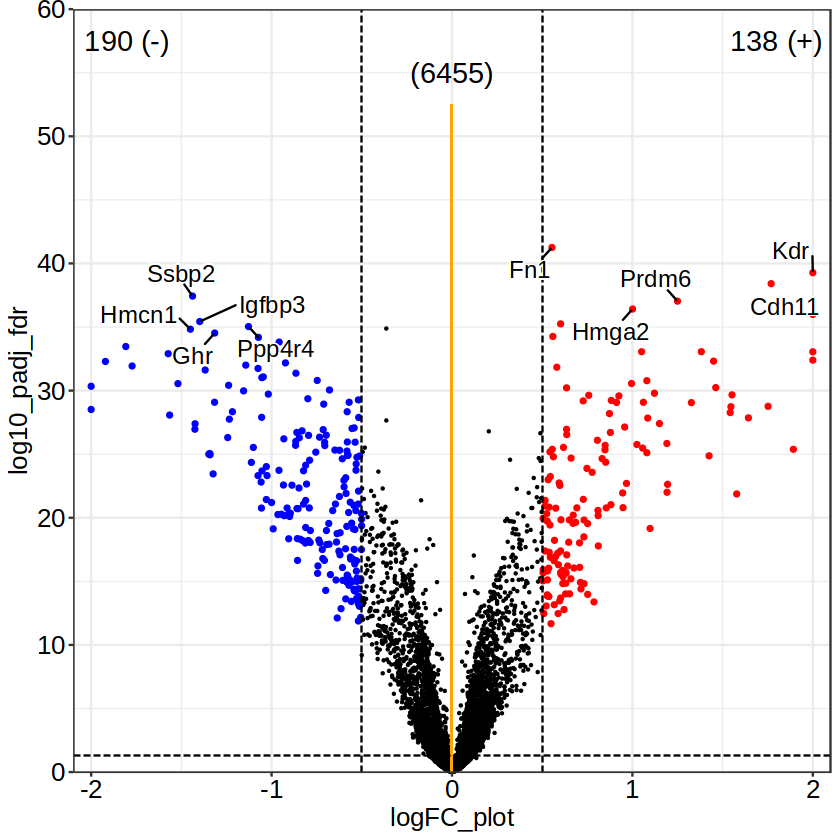

In [28]:
volcano_plot(DEGs, xlim = 2, ylim = 50, logFC_thr = 0.5)

In [30]:
fwrite(DEGs, file.path(args$outdir, 'DEGs_edgeR.csv'), sep = ',')

In [23]:
head(DEGs[gene == 'Eomes'])

gene,logFC,padj_fdr,mean_groupA,mean_groupB,cdr_groupA,cdr_groupB,sign
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Eomes,0.93,3.07e-30,1.2,1.19,0.84,0.65,pos


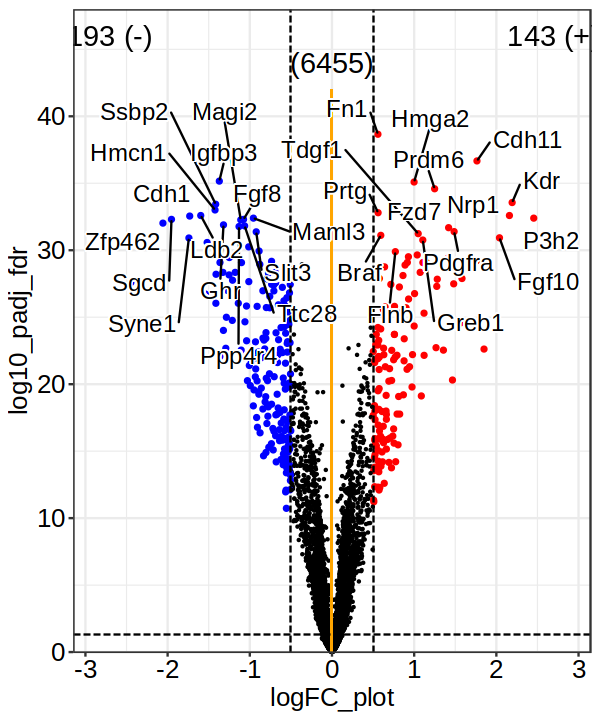

In [24]:
options(repr.plot.width = 5, repr.plot.height = 6)
volcano_plot(DEGs, xlim = 3, ylim = 40, logFC_thr = 0.5, ntop = 15)

In [25]:
# Gene Ontology
GO_plot = function(plot){
    ggplot(plot, 
           aes(enrichment, Term, color = -log10(FDR), fill = -log10(FDR), size = DE)) +  #, 
        geom_bar(stat = 'identity', aes(fill = -log10(FDR)), color = NA,  width = 0.05) +
        geom_point() + 
        geom_text(aes(x = max(plot$enrichment)/100, label = Term), vjust = -0.5, hjust = 0, color = 'black', size = 5 * 0.35) + 
        guides(fill = guide_colourbar(
             barwidth = 0.5, barheight = 2.5,
            frame.colour = "black", 
            ticks.colour = "black"
        )) + 
        scale_size(range = c(0, 1)) + 
        scale_fill_gradientn(colors = c('white', 'blue', 'red'), limits = c(0, max(-log10(plot$FDR))), name = '-log10(FDR)') + 
        scale_color_gradientn(colors = c('white', 'blue', 'red'), limits = c(0, max(-log10(plot$FDR))), name = '-log10(FDR)') + 
        scale_x_continuous(limits = c(0, max(plot$enrichment)), expand = c(0,0,0,3)) + 
        scale_y_discrete(expand = c(0,0.3,0,1.5)) + 
        theme_bw() + 
        theme(axis.text = element_text(size = 5, color = 'black'),
                axis.text.y = element_blank(), 
                axis.ticks.y = element_blank(),
                axis.title.x = element_text(size = 7),
                axis.title.y = element_blank(),
                panel.border = element_rect(color='black', linewidth=0.5, fill = NA),
                panel.background = element_rect(fill = 'white'),
                panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
             #   plot.margin = margin(0, 0, 0, 0),  # Adjust the margin around the plot
                # legend.margin = margin(0, 0, 0, 0),  # Adjust the margin inside the legend box
                # legend.box.margin = margin(0, 0, 0, 0),  # Adjust the margin outside the legend box
                legend.key.size  = unit(1, "mm"),
                legend.key = element_blank(),
                legend.position = 'right')
}

genes = DEGs[sign == 'pos', gene]
tmp = do_GO(genes, background = rownames(rna.sce))
p1 = GO_plot(tmp[[1]] %>% copy() %>%
           .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 20 & N < 1000 & DE > 3 & enrichment > 3] %>% .[order(-enrichment)] %>% 
           # .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50 & N < 1000 & DE > 3 & enrichment > 5] %>% .[order(FDR)] %>% 
            .[,Term := factor(Term, levels = rev(Term))] %>% 
            .[, enrichment := ifelse(enrichment > 100, 100, enrichment)] %>% 
            head(7)
)

genes = DEGs[sign == 'neg', gene]
tmp = do_GO(genes, background = rownames(rna.sce))
p2 = GO_plot(tmp[[1]] %>% copy() %>%
           .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 20 & N < 1000 & DE > 3 & enrichment > 3] %>% .[order(-enrichment)] %>% 
           # .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50 & N < 1000 & DE > 3 & enrichment > 5] %>% .[order(FDR)] %>% 
            .[,Term := factor(Term, levels = rev(Term))] %>% 
            .[, enrichment := ifelse(enrichment > 100, 100, enrichment)] %>% 
            head(7)
)


'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



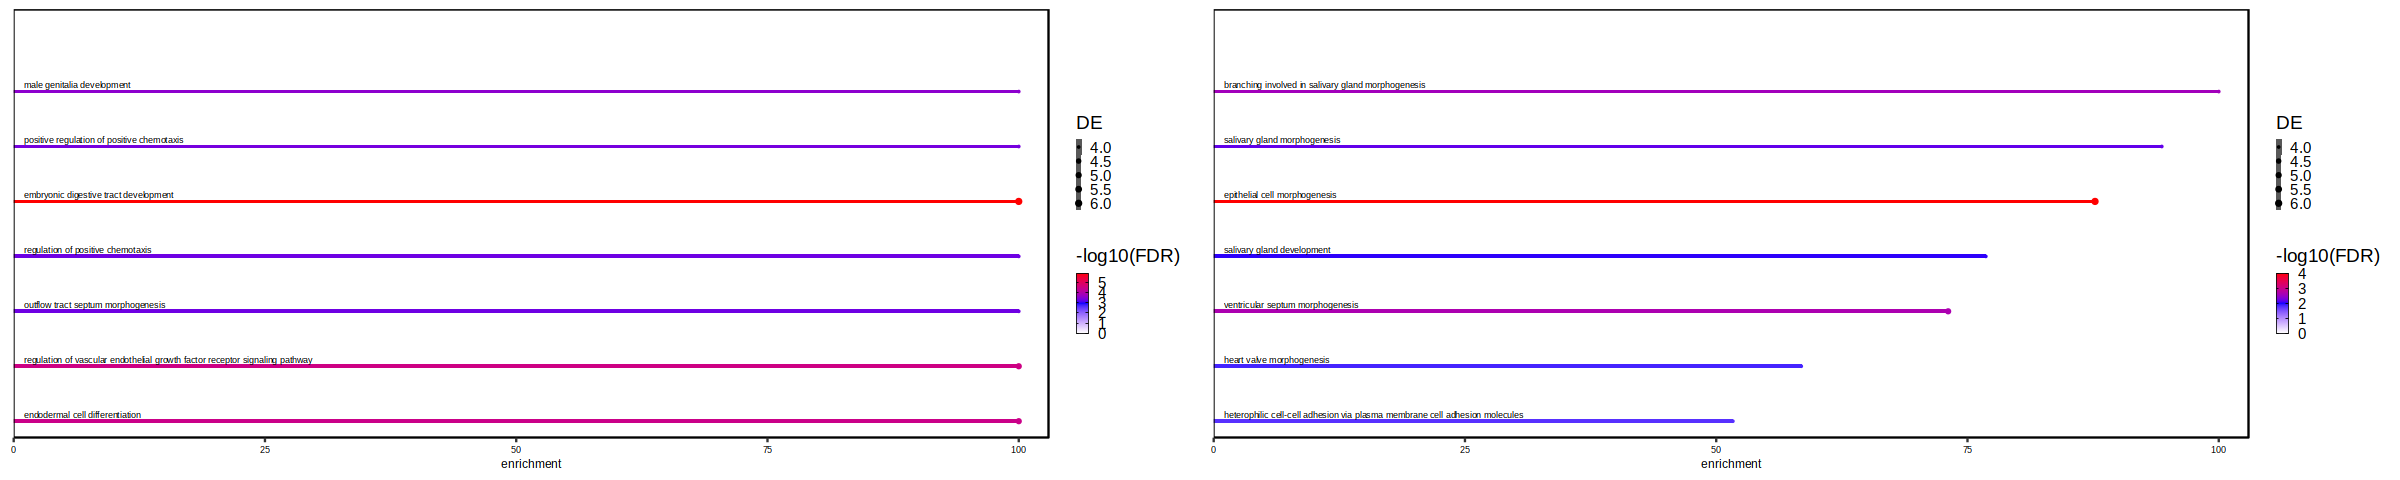

In [26]:
options(repr.plot.width = 20, repr.plot.height = 4)
ggarrange(p1, p2, align = 'hv')

In [27]:
genes = DEGs[sign == 'pos', gene]
tmp = do_GO(genes, background = rownames(rna.sce))
tmp[[1]] %>% copy() %>%
           .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 20 & N < 1000 & DE > 10 & enrichment > 3] %>% .[order(-enrichment)]

'select()' returned 1:many mapping between keys and columns



GOALL,Term,Ont,N,DE,P.DE,FDR,enrichment,genes
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
GO:0010811,positive regulation of cell-substrate adhesion,BP,137,15,1.293291e-16,6.163880e-14,25.801854,"Braf, Cdh13, Fbln1, Fbln2, Fn1, Has2, Foxf1, Itga5, Kdr, Nrp1, Pcsk5, Prkce, Ptprj, Tdgf1, Prex1"
GO:0007369,gastrulation,BP,182,12,6.627819e-11,1.365988e-08,11.696051,"Eomes, Fn1, Fzd7, Gata4, Gata6, Foxf1, Hmga2, Itga5, Smad1, Tdgf1, Tenm4, Crb2"
GO:0010810,regulation of cell-substrate adhesion,BP,223,18,2.567920e-17,1.468658e-14,11.685938,"Kank1, Braf, Cdh13, Fbln1, Fbln2, Fn1, Fzd7, Has2, Foxf1, Itga5, Kdr, Nrp1, Pcsk5, Prkce, Ptprj, Tdgf1, Prex1, Dlc1"
GO:0048754,branching morphogenesis of an epithelial tube,BP,191,11,1.687409e-09,2.523062e-07,9.734793,"Col4a1, Fgf10, Foxf1, Hmga2, Kdr, Ncoa3, Nrp1, Pdgfra, Tbx3, Hs3st3b1, Tbx20"
GO:0035265,organ growth,BP,212,12,5.008371e-10,8.746297e-08,8.620061,"Cacna1c, Fgf10, Gata4, Gata6, Kdr, Smad1, Ncam1, Pdgfra, Tcf7l2, Tenm4, Cacna2d2, Tbx20"
GO:0007160,cell-matrix adhesion,BP,231,13,7.785393e-11,1.576163e-08,7.865389,"Adamts9, Itga9, Cdh13, Col13a1, Fn1, Itga5, Itgb5, Kdr, Nrp1, Pcsk5, Ptprj, Tdgf1, Dlc1"
GO:0098742,cell-cell adhesion via plasma-membrane adhesion molecules,BP,216,11,6.425936e-09,8.121886e-07,7.611776,"Cdh11, Cdh13, Cdh4, Itga5, Robo1, Prtg, Tenm4, Crb2, Nrcam, Clstn2, Pcdh18"
GO:0061138,morphogenesis of a branching epithelium,BP,229,11,1.123284e-08,1.338405e-06,6.772087,"Col4a1, Fgf10, Foxf1, Hmga2, Kdr, Ncoa3, Nrp1, Pdgfra, Tbx3, Hs3st3b1, Tbx20"
GO:0001763,morphogenesis of a branching structure,BP,249,13,1.772417e-10,3.378964e-08,6.769326,"Col13a1, Col4a1, Fgf10, Foxf1, Hmga2, Kdr, Ncoa3, Nrp1, Pdgfra, Tbx3, Tdgf1, Hs3st3b1, Tbx20"


In [28]:
genes = DEGs[sign == 'neg', gene]
tmp = do_GO(genes, background = rownames(rna.sce))
tmp[[1]] %>% copy() %>%
           .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 20 & N < 1000 & DE > 10 & enrichment > 3] %>% .[order(-enrichment)]

'select()' returned 1:many mapping between keys and columns



GOALL,Term,Ont,N,DE,P.DE,FDR,enrichment,genes
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
GO:0016331,morphogenesis of embryonic epithelium,BP,184,11,3.762351e-08,7.616930e-06,10.489573,"Prickle1, Celsr1, Fgf8, Lama5, Nodal, Spint1, Spint2, T, Tgfb2, Grsf1, Shroom3"
GO:0048839,inner ear development,BP,215,12,2.047547e-08,4.419032e-06,8.381179,"Abr, Cdh1, Celsr1, Fgf8, Gabrb3, H2-K1, Lrig1, Esrp1, Tgfb2, Frem2, Fat4, Ahi1"
GO:0098742,cell-cell adhesion via plasma-membrane adhesion molecules,BP,216,12,1.671656e-08,3.712863e-06,8.303755,"Alcam, Cdh1, Cdh6, Celsr1, Dscam, Epcam, Nrxn1, Tgfb2, Fat4, Magi2, Hmcn1, Palld"
GO:0043583,ear development,BP,248,13,1.052465e-08,2.577514e-06,6.824028,"Abr, Shroom2, Cdh1, Celsr1, Fgf8, Gabrb3, H2-K1, Lrig1, Esrp1, Tgfb2, Frem2, Fat4, Ahi1"
GO:0061138,morphogenesis of a branching epithelium,BP,229,11,2.776586e-07,4.602895e-05,6.772087,"Cdh1, Celsr1, Fgf8, Lama5, Pml, Slit2, Spint1, Spint2, Esrp1, Fat4, Rspo3"
GO:0002064,epithelial cell development,BP,234,11,5.431998e-07,8.284521e-05,6.485773,"Cdh1, Col18a1, Id1, F11r, Spint2, Tjp2, Ezr, Shroom3, Zdhhc21, Ccdc88c, Palld"
GO:0001763,morphogenesis of a branching structure,BP,249,12,7.602173e-08,1.437313e-05,6.248609,"Cdh1, Celsr1, Fgf8, Lama5, Ctnnd2, Pml, Slit2, Spint1, Spint2, Esrp1, Fat4, Rspo3"
GO:0003007,heart morphogenesis,BP,272,12,3.025640e-07,4.944112e-05,5.236538,"Fgf8, Id2, Nodal, Pdcd4, Slit2, Slit3, T, Tgfb2, Tpm1, Zfpm2, Fat4, Ahi1"
GO:2000146,negative regulation of cell motility,BP,321,16,3.517188e-10,1.166126e-07,5.013150,"Abr, Cdh1, Igfbp3, Nodal, Ptprk, Slit2, Spint2, Tpm1, Frmd5, Mcc, Magi2, Ldlrad4, Trp53inp1, Ifitm3, Bst2, Limch1"


## ATAC analysis

In [31]:
suppressPackageStartupMessages(library(ArchR))
addArchRThreads(32)

Setting default number of Parallel threads to 32.



In [32]:
ArchRProject <- loadArchRProject(io$archR.directory)[meta$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [33]:
# Create new SCE to prepare for pseudobulking
atac.sce = getMatrixFromProject(
                  ArchRProj = ArchRProject,
                  useMatrix = "PeakMatrix")
atac.sce$celltype_v2 = meta[match(colnames(atac.sce), cell), celltype_v2] # add cell type
assayNames(atac.sce) <- "counts"

# prepare replicates
sce = atac.sce[,cell2replicate.dt$cell] 
sce$group_by <- cell2replicate.dt$replicate

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-21070790c09d5-Date-2024-12-03_Time-14-48-08.log
If there is an issue, please report to github with logFile!

2024-12-03 14:48:58 : Organizing colData, 0.829 mins elapsed.

2024-12-03 14:48:58 : Organizing rowData, 0.834 mins elapsed.

2024-12-03 14:48:58 : Organizing rowRanges, 0.834 mins elapsed.

2024-12-03 14:48:58 : Organizing Assays (1 of 1), 0.834 mins elapsed.

2024-12-03 14:49:18 : Constructing SummarizedExperiment, 1.176 mins elapsed.

2024-12-03 14:49:41 : Finished Matrix Creation, 1.546 mins elapsed.



In [34]:
################
## Pseudobulk ##
################
BPPARAM$workers = 24 # for some reason crashed when not using this
sce_full = scuttle::aggregateAcrossCells(sce, id=sce$group_by, BPPARAM = BPPARAM)

assayNames(sce_full) <- "counts"
sce_full = as(sce_full, 'SingleCellExperiment')
rm(sce)

###################
## Normalisation ##
###################
# log cpm
logcounts(sce_full) <- log2(1e6*(sweep(counts(sce_full),2,colSums(counts(sce_full)),"/"))+1)

In [35]:
# prepare single-cell ATAC for CDR
atac.sce = as(atac.sce, 'SingleCellExperiment')
atac.sce = atac.sce[,cell_metadata.dt$cell]
summary(colnames(atac.sce) == cell_metadata.dt$cell)

# Get peakset
peakSet = as.data.table(ArchRProject@peakSet) %>% 
    .[, feature:=paste0(seqnames, ':', start, '-', end)] %>%
    .[,idx:=1:nrow(.)] %>%
    .[,c('feature', 'idx')]
features = peakSet$feature

# fix other things
assayNames(atac.sce) <- "counts"
rownames(atac.sce) = features
rownames(sce_full) = features

   Mode    TRUE 
logical   19740 

In [36]:
atac.sce
sce_full

class: SingleCellExperiment 
dim: 234908 19740 
metadata(0):
assays(1): counts
rownames(234908): chr1:3003470-3004070 chr1:3035598-3036198 ...
  chrX:169925416-169926016 chrX:169937236-169937836
rowData names(1): idx
colnames(19740): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_control#TTTGTGGCATCCCTCA-1
  rv_eo_deg_day4_control#TTTGTGTTCCTGAATA-1
colData names(40): BlacklistRatio nDiFrags ... replicate celltype_v2
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

class: SingleCellExperiment 
dim: 234908 60 
metadata(0):
assays(2): counts logcounts
rownames(234908): chr1:3003470-3004070 chr1:3035598-3036198 ...
  chrX:169925416-169926016 chrX:169937236-169937836
rowData names(1): idx
colnames(60): Allantois_Precursor.WT_rep1 Allantois_Precursor.WT_rep2
  ... Primitive_Streak.WT_rep4 Primitive_Streak.WT_rep5
colData names(43): BlacklistRatio nDiFrags ... ids ncells
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [37]:
# ct =  'Early_Mes_EOd'
# min.expr = 0.5
# min.cdr = 0.2

find_DARs = function(celltype1, celltype2, min.expr = 0.3, min.cdr = 0.15){
      message(paste0(celltype1, ' vs ', celltype2))
      sce <- sce_full[,sce_full$celltype_v2 %in% c(celltype1, celltype2)]
      sce$group = factor(ifelse(sce$celltype_v2 == celltype2, 'fg', 'bg'), levels = c('fg', 'bg'))
      singlecell_sce <- atac.sce[,atac.sce$celltype_v2 %in% c(celltype1, celltype2)]

        #######################################
        ## Calculate Cellular Detection Rate ##
        #######################################
        expr.dt <- data.table(
          gene = rownames(atac.sce),
          mean_groupA = rowMeans(logcounts(sce[,sce$celltype_v2 == celltype1])) %>% round(2),
          mean_groupB = rowMeans(logcounts(sce[,sce$celltype_v2 == celltype2])) %>% round(2),
          cdr_groupA = rowMeans(counts(singlecell_sce[,singlecell_sce$celltype_v2 == celltype1])>0) %>% round(2),
          cdr_groupB = rowMeans(counts(singlecell_sce[,singlecell_sce$celltype_v2 == celltype2])>0) %>% round(2)
        )

        #######################
        ## Feature selection ##
        #######################
        # Filter features
        features.to.use <- expr.dt[mean_groupA>=min.expr | mean_groupB>=min.expr,][cdr_groupA>=min.cdr | cdr_groupB>=min.cdr,gene]
        message(paste0('Nr of peaks: ', length(features.to.use)))
        ################################################
        ## Differential expression testing with edgeR ##
        ################################################

        # Convert SCE to DGEList
        sce_edger <- scran::convertTo(sce[features.to.use,], type="edgeR")
        
        # Calculate Normalisation Factors
        sce_edger <- calcNormFactors(sce_edger)
        
        # Define design matrix (with intercept)
        design <- model.matrix(~sce$group)

        # Estimate dispersions
        sce_edger  <- estimateDisp(sce_edger,design)

        # Fit GLM
        fit <- glmQLFit(sce_edger,design)

        # Likelihood ratio test
        lrt <- glmQLFTest(fit)

        # Construct output data.frame
        out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
          .[,idx:=NULL] %>% 
          setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
          .[,c("logCPM","LR","p.value"):=NULL] %>%
          .[,c("padj_fdr","logFC"):=list(signif(padj_fdr,digits=3), round(logFC,3))] %>%
          merge(expr.dt, by="gene", all.y=TRUE) %>%
          setorder(padj_fdr, na.last=T) %>%
          .[!is.na(logFC)]
    
        return(out)
}

In [38]:
DARs = find_DARs('Early_Mes_EOd', 'Early_Mes_EOi')

Early_Mes_EOd vs Early_Mes_EOi

Nr of peaks: 32740

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [39]:
fwrite(DARs, file.path(args$outdir, 'DARs_edgeR.csv'), sep = ',')

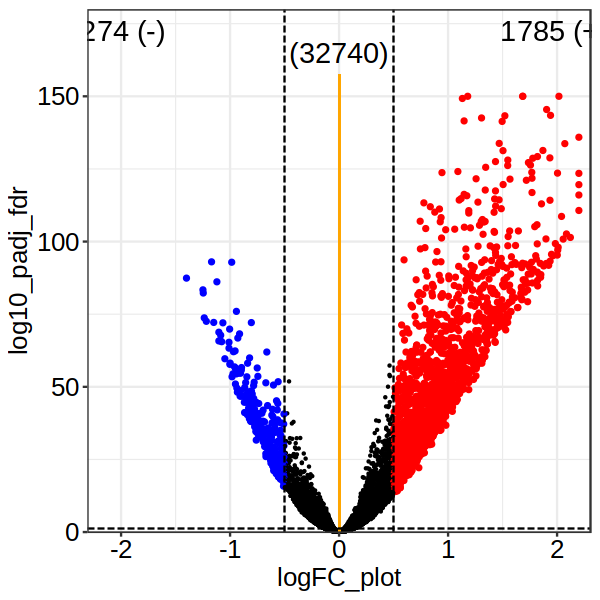

In [40]:
options(repr.plot.width = 5, repr.plot.height = 5)
volcano_plot(DARs, xlim = 2.2, ylim = 150, logFC_thr = 0.5, ntop = 0)

In [41]:
# matches <- getMatches(ArchRProject, 'Motif_cisbp')
# rownames(matches) = rownames(atac.sce)

io$multiome = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/'
silico_chip = readRDS(file.path(io$multiome, 'vitro_peaks_silicoChIP_cisbp.rds'))
assay(silico_chip, 'matches') = assay(silico_chip, 'VirtualChipScores') > 0.2 # keep only motifs with in silico score > 0.2
assay(silico_chip, 'motifScores') = NULL
assay(silico_chip, 'motifMatches') = NULL
assay(silico_chip, 'motifCounts') = NULL
assay(silico_chip, 'VirtualChipScores') = NULL
matches = silico_chip

# Need to re-run in silico ChIP on new peak set...
# Definitely do this in the future...
# for now:
# matches = motifmatcher.se

In [42]:
head(DARs)

gene,logFC,padj_fdr,mean_groupA,mean_groupB,cdr_groupA,cdr_groupB,sign
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr7:46454349-46454949,2.017,9.86e-160,4.36,2.56,0.30,0.08,pos
chr1:128551897-128552497,1.684,4.20e-159,4.60,3.05,0.34,0.11,pos
chr18:82897845-82898445,1.686,9.25e-155,4.54,3.00,0.34,0.10,pos
chr18:80624992-80625592,1.180,7.88e-151,5.05,3.94,0.45,0.20,pos
chr7:142330308-142330908,1.131,5.63e-150,5.09,4.03,0.45,0.19,pos
chr7:82890994-82891594,1.904,3.53e-146,4.26,2.56,0.28,0.08,pos


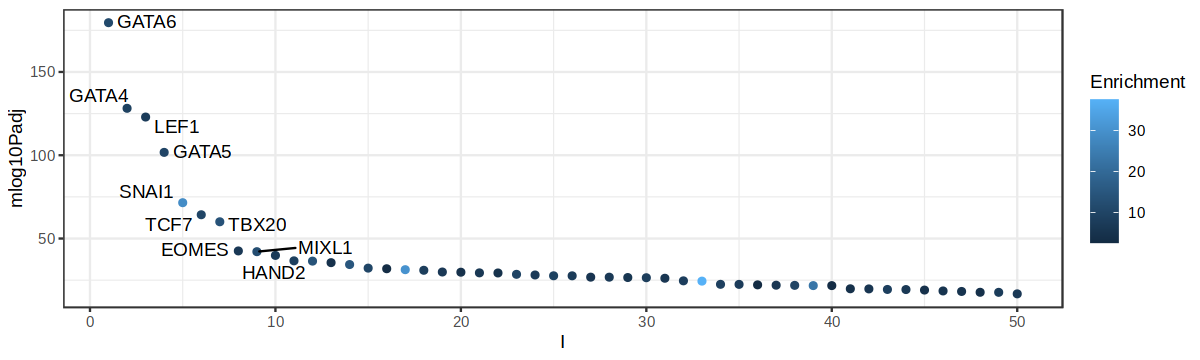

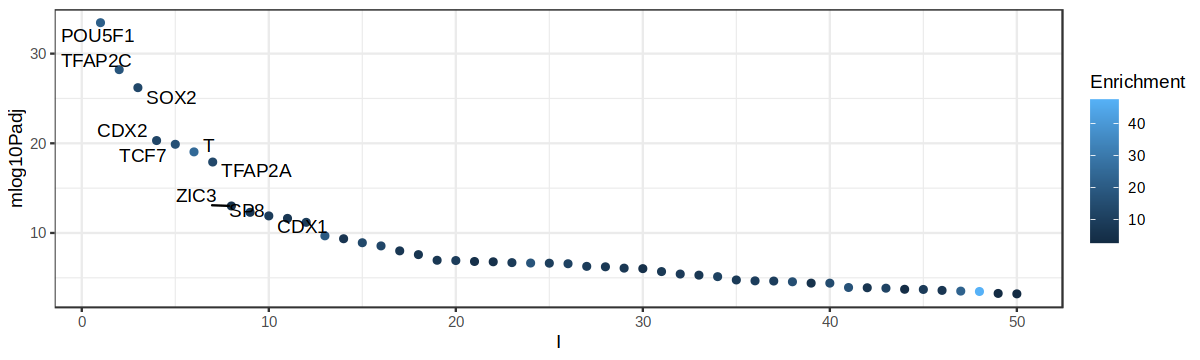

In [43]:
options(repr.plot.width = 10, repr.plot.height = 3)

tmp2 = as.data.table(ArchR:::.computeEnrichment(matches, DARs[sign == 'pos', gene], seq_len(nrow(matches)))) %>%
        .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
        .[mlog10Padj > -log10(0.05)]

to.plot = tmp2[order(-mlog10Padj)] %>% .[,I := .I]
ggplot(head(to.plot, 50), aes(I, mlog10Padj, color = Enrichment)) + 
    geom_point() + 
    ggrepel::geom_text_repel(data = head(to.plot,10), aes(label = feature), color = 'black') + 
    theme_bw()

tmp2 = as.data.table(ArchR:::.computeEnrichment(matches, DARs[sign == 'neg', gene], seq_len(nrow(matches)))) %>%
        .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
        .[mlog10Padj > -log10(0.05)]

to.plot = tmp2[order(-mlog10Padj)] %>% .[,I := .I]
ggplot(head(to.plot, 50), aes(I, mlog10Padj, color = Enrichment)) + 
    geom_point() + 
    ggrepel::geom_text_repel(data = head(to.plot,10), aes(label = feature), color = 'black') + 
    theme_bw()

In [44]:
tmp2 = as.data.table(ArchR:::.computeEnrichment(matches, DARs[sign == 'pos', gene], seq_len(nrow(matches)))) %>%
        .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
        .[mlog10Padj > -log10(0.05)]

to.plot = tmp2[order(-mlog10Padj)] %>% .[,I := .I]

fwrite(to.plot, file.path(args$outdir, 'DARs_edgeR_motif_pos.csv'), sep = ',')

tmp2 = as.data.table(ArchR:::.computeEnrichment(matches, DARs[sign == 'neg', gene], seq_len(nrow(matches)))) %>%
        .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
        .[mlog10Padj > -log10(0.05)]

to.plot = tmp2[order(-mlog10Padj)] %>% .[,I := .I]

fwrite(to.plot, file.path(args$outdir, 'DARs_edgeR_motif_neg.csv'), sep = ',')

In [45]:
ArchRProject <- addCellColData(ArchRProj = ArchRProject, 
                                    data = as.character(meta$celltype_v2),
                                    cells = meta$cell,
                                    name = "celltype_v2",
                                    force=TRUE)

In [46]:
markers = getMarkerFeatures(
        ArchRProj = ArchRProject,
        groupBy = "celltype_v2",
        useGroups = 'Early_Mes_EOd',
        bgdGroups = 'Early_Mes_EOi',
        useMatrix = "PeakMatrix",
      testMethod = "binomial",
  binarize = TRUE,

        verbose = F)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-210706d7516fe-Date-2024-12-03_Time-14-50-17.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

Pairwise Test Early_Mes_EOd : Seqnames chr1

Pairwise Test Early_Mes_EOd : Seqnames chr10

Pairwise Test Early_Mes_EOd : Seqnames chr11

Pairwise Test Early_Mes_EOd : Seqnames chr12

Pairwise Test Early_Mes_EOd : Seqnames chr13

Pairwise Test Early_Mes_EOd : Seqnames chr14

Pairwise Test Early_Mes_EOd : Seqnames chr15

Pairwise Test Early_Mes_EOd : Seqnames chr16

Pairwise Test Early_Mes_EOd : Seqnames chr17

Pairwise Test Early_Mes_EOd : Seqnames chr18

Pairwise Test Early_Mes_EOd : Seqnames chr19

Pairwise Test Early_Mes_EOd : Seqnames chr2

Pairwise Test Early_Mes_EOd : Seqnames chr3

Pairwise Test Early_Mes_EOd : Seqnames chr4

Pairwise Test Early_Mes_EOd : Seqnames chr5

Pairwise Test Early_Mes_EOd : Seqnames chr6

Pairwise Test Early_Mes_EOd : Seqnames chr7

Pairwise Test Early_Mes_EO

In [47]:
DARs2 = data.table(peak = paste0(rowData(markers)$seqnames, ':', rowData(markers)$start, '-', rowData(markers)$end),
                              FDR = assay(markers[,1], 'FDR')[[1]],
                              log2FC = assay(markers[,1], 'Log2FC')[[1]]) %>% 
                    .[order(FDR)]

In [48]:
fwrite(DARs2, file.path(args$outdir, 'DARs_archr.csv'), sep = ',')

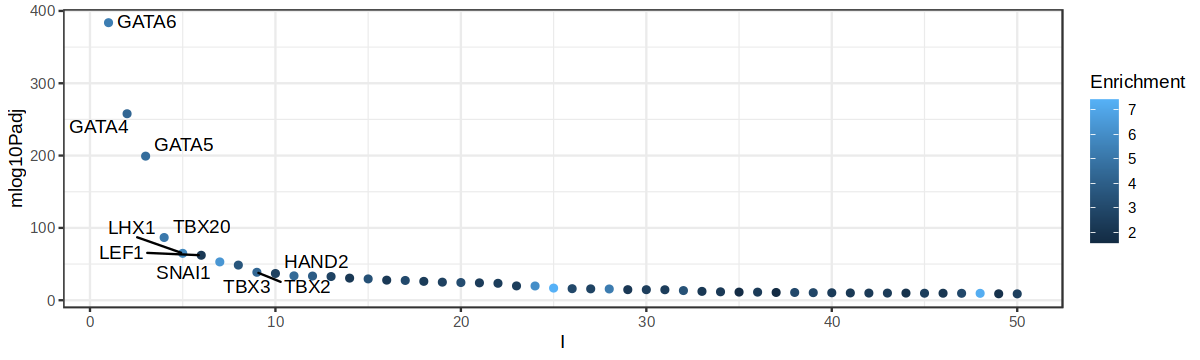

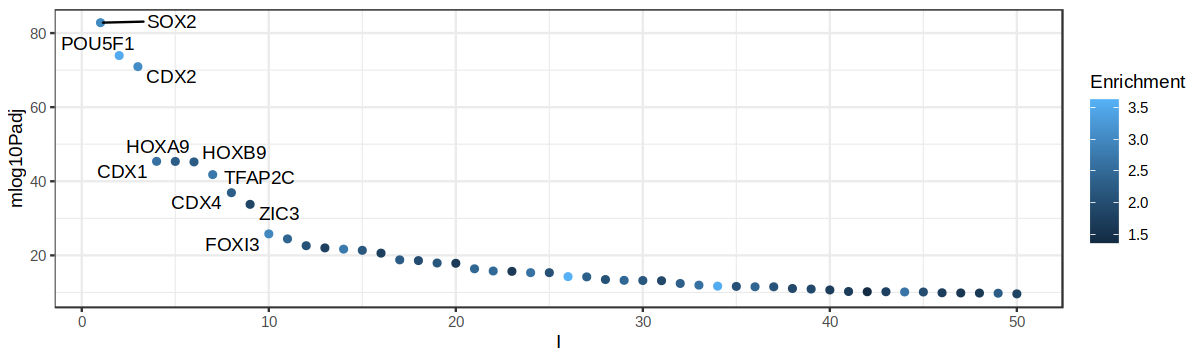

In [49]:
options(repr.plot.width = 10, repr.plot.height = 3)

tmp2 = as.data.table(ArchR:::.computeEnrichment(matches, DARs2[log2FC > 0.5 & FDR < 5e-2, peak], seq_len(nrow(matches)))) %>%
        .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
        .[mlog10Padj > -log10(0.05)]

to.plot = tmp2[order(-mlog10Padj)] %>% .[,I := .I]
ggplot(head(to.plot, 50), aes(I, mlog10Padj, color = Enrichment)) + 
    geom_point() + 
    ggrepel::geom_text_repel(data = head(to.plot,10), aes(label = feature), color = 'black') + 
    theme_bw()

tmp2 = as.data.table(ArchR:::.computeEnrichment(matches, DARs2[log2FC < 0.5 & FDR < 5e-2, peak], seq_len(nrow(matches)))) %>%
        .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
        .[mlog10Padj > -log10(0.05)]

to.plot = tmp2[order(-mlog10Padj)] %>% .[,I := .I]
ggplot(head(to.plot, 50), aes(I, mlog10Padj, color = Enrichment)) + 
    geom_point() + 
    ggrepel::geom_text_repel(data = head(to.plot,10), aes(label = feature), color = 'black') + 
    theme_bw()

In [50]:
tmp2 = as.data.table(ArchR:::.computeEnrichment(matches, DARs[sign == 'pos', gene], seq_len(nrow(matches)))) %>%
        .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
        .[mlog10Padj > -log10(0.05)]

to.plot = tmp2[order(-mlog10Padj)] %>% .[,I := .I]

fwrite(to.plot, file.path(args$outdir, 'DARs_archr_motif_pos.csv'), sep = ',')

tmp2 = as.data.table(ArchR:::.computeEnrichment(matches, DARs[sign == 'neg', gene], seq_len(nrow(matches)))) %>%
        .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
        .[mlog10Padj > -log10(0.05)]

to.plot = tmp2[order(-mlog10Padj)] %>% .[,I := .I]

fwrite(to.plot, file.path(args$outdir, 'DARs_archr_motif_neg.csv'), sep = ',')

# ChromVAR comparison!!!

In [51]:
getAvailableMatrices(ArchRProject)

[1] "DeviationMatrix_CISBP"   "DeviationMatrix_JASPAR" 
 [3] "GeneScoreMatrix_TSS"     "GeneScoreMatrix_distal" 
 [5] "MarkerPeaksMatrix"       "MotifMatrix"            
 [7] "PeakMatrix"              "PeakMatrix_atlas"       
 [9] "TileMatrix"              "silicoChIP_CISBPMatrix" 
[11] "silicoChIP_CISBP_v2"     "silicoChIP_JASPARMatrix"
[13] "silicoChIP_JASPAR_v2"

In [52]:
diffMotif = getMarkerFeatures(
        ArchRProj = ArchRProject,
        groupBy = "celltype_v2",
        useGroups = 'Early_Mes_EOi',
        bgdGroups = 'Early_Mes_EOd',
        useMatrix = "silicoChIP_CISBP_v2",
        useSeqnames = 'z',
        verbose = F)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-2107069741174-Date-2024-12-03_Time-14-51-07.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Assays.Matrix

Pairwise Test Early_Mes_EOi : Seqnames z

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-2107069741174-Date-2024-12-03_Time-14-51-07.log



In [53]:
diffMotif.dt = lapply(colnames(diffMotif), function(x){
    tmp = data.table(motif = str_split(rowData(diffMotif)$name, '_') %>% map_chr(1),
                                  FDR = assay(diffMotif[,x], 'FDR')[[1]],
                                  MeanDiff = assay(diffMotif[,x], 'MeanDiff')[[1]]) %>% 
                        .[order(-MeanDiff)] %>% 
                        .[,celltype_v2 := x]
    return(tmp)
}) %>% rbindlist() %>% .[MeanDiff != Inf]

In [54]:
fwrite(diffMotif.dt, file.path(args$outdir, 'diffChromVar_silicochip.csv'), sep = ',')

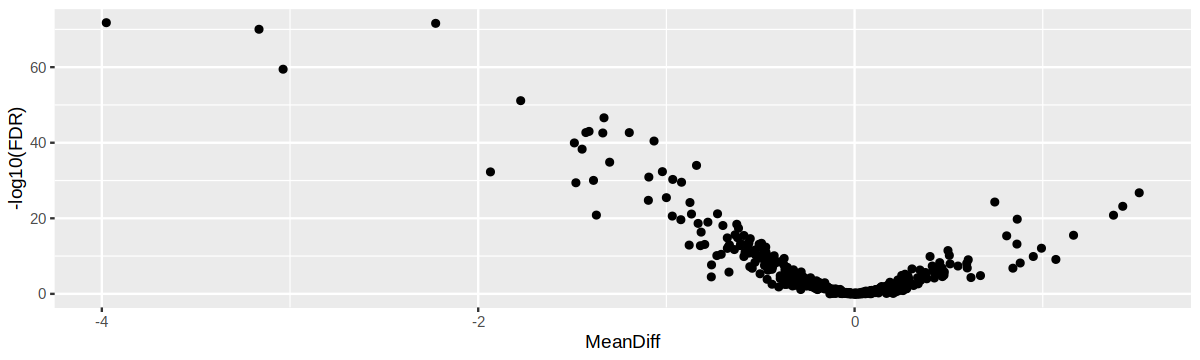

In [55]:
ggplot(diffMotif.dt, aes(MeanDiff, -log10(FDR))) + 
    geom_point()

In [56]:
head(diffMotif.dt, 8)
tail(diffMotif.dt, 8)

motif,FDR,MeanDiff,celltype_v2
<chr>,<dbl>,<dbl>,<chr>
TFAP2C,1.770134e-27,1.5125595,Early_Mes_EOi
SOX2,6.724976e-24,1.4250693,Early_Mes_EOi
CDX2,1.533863e-21,1.3758635,Early_Mes_EOi
TFAP2A,3.081478e-16,1.1635044,Early_Mes_EOi
HOXA9,7.778184e-10,1.0696529,Early_Mes_EOi
CDX1,8.335365e-13,0.9930758,Early_Mes_EOi
POU5F1,1.289584e-10,0.9496892,Early_Mes_EOi
CDX4,6.815070e-09,0.8801454,Early_Mes_EOi


motif,FDR,MeanDiff,celltype_v2
<chr>,<dbl>,<dbl>,<chr>
HAND2,3.953712e-30,-1.480886,Early_Mes_EOi
LHX1,1.128973e-40,-1.489024,Early_Mes_EOi
SNAI1,7.351792e-52,-1.774248,Early_Mes_EOi
LEF1,5.245710e-33,-1.934893,Early_Mes_EOi
TBX20,2.522120e-72,-2.226068,Early_Mes_EOi
GATA5,3.483106e-60,-3.036763,Early_Mes_EOi
GATA4,9.342831e-71,-3.164833,Early_Mes_EOi
GATA6,1.688226e-72,-3.976190,Early_Mes_EOi


In [50]:
diffMotif.dt[motif == 'EOMES']

motif,FDR,MeanDiff,celltype_v2
<chr>,<dbl>,<dbl>,<chr>
EOMES,3.239685e-05,-0.7613385,Early_Mes_EOi


In [58]:
sce

ERROR: Error in eval(expr, envir, enclos): object 'sce' not found


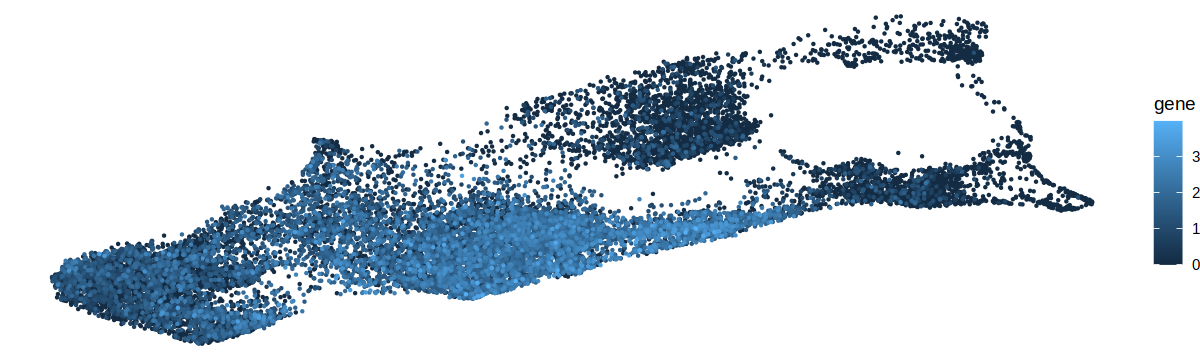

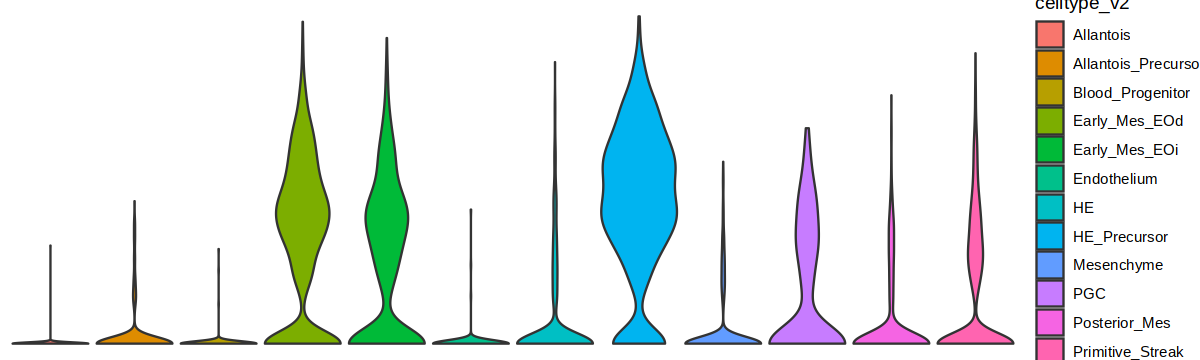

In [66]:
gene = 'Mixl1'
meta$gene = as.vector(logcounts(rna.sce[gene, meta$cell]))
ggplot(meta[order(gene)], aes(UMAP1, UMAP2, color = gene)) + 
    geom_point(size = 0.2) + 
    theme_void()

ggplot(meta[order(gene)], aes(celltype_v2, gene, fill = celltype_v2)) + 
    geom_violin(scale = 'width') + 
    theme_void()